# Moment Flow vs DSEC Ground Truth Analysis

Use this notebook after running `event_detector_cpp` with raw-flow saving enabled. It loads the DSEC ground-truth flow PNGs, the saved MomentFlow predictions in `logs/moment_flow`, and the benchmark summary. The goal is not just to report the score, but to isolate likely failure modes: timestamp alignment, DSEC PNG channel order, sign conventions, scale errors, spatially localized failures, and outlier frames.

In [141]:
from pathlib import Path
import json
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find the workspace root whether the notebook is opened from the root or this folder.
ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src/event_detector_cpp").exists() and (candidate / "tools/dsec_flow_benchmark").exists():
        ROOT = candidate
        break

sys.path.insert(0, str(ROOT))

from tools.dsec_flow_benchmark.flow_io import load_dsec_png
from tools.dsec_flow_benchmark.timestamps import load_timestamps

GT_DIR = ROOT / "logs/dsec/thun_00_a/optical_flow_foward"
PRED_DIR = ROOT / "logs/moment_flow/thun_00_a"
TIMESTAMP_FILE = GT_DIR / "thun_00_a_optical_flow_forward_timestamps.txt"
RESULT_JSON = PRED_DIR / "benchmark.json"
RESULT_CSV = PRED_DIR / "benchmark_frames.csv"

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})


def png_names(directory):
    return sorted(path.name for path in Path(directory).glob("*.png"))


def read_result_frame_names():
    if not RESULT_CSV.exists():
        return []
    try:
        frame_df = pd.read_csv(RESULT_CSV)
    except Exception:
        return []
    if "frame" not in frame_df.columns:
        return []
    return sorted(frame_df["frame"].astype(str).tolist())


def benchmark_current_status():
    gt_names = png_names(GT_DIR)
    pred_names = png_names(PRED_DIR)
    expected = sorted(set(gt_names) & set(pred_names))
    csv_frames = read_result_frame_names()
    reasons = []

    if not gt_names:
        reasons.append(f"No ground-truth PNGs found in {GT_DIR}")
    if not pred_names:
        reasons.append(f"No prediction PNGs found in {PRED_DIR}")
    if not RESULT_JSON.exists() or not RESULT_CSV.exists():
        reasons.append("Benchmark metric files are missing")

    stale_csv = sorted(name for name in csv_frames if name not in gt_names or name not in pred_names)
    missing_csv = sorted(name for name in expected if name not in set(csv_frames))
    if RESULT_CSV.exists() and not csv_frames:
        reasons.append("Benchmark CSV exists but has no readable frame rows")
    if stale_csv:
        reasons.append(f"Benchmark CSV references {len(stale_csv)} frame(s) not present on disk")
    if missing_csv:
        reasons.append(f"Benchmark CSV is missing {len(missing_csv)} current prediction frame(s)")

    current = bool(expected) and RESULT_JSON.exists() and RESULT_CSV.exists() and not stale_csv and not missing_csv
    return {
        "current": current,
        "can_run": bool(expected),
        "gt_names": gt_names,
        "pred_names": pred_names,
        "expected": expected,
        "csv_frames": csv_frames,
        "stale_csv": stale_csv,
        "missing_csv": missing_csv,
        "reasons": reasons,
    }


print("ROOT:", ROOT)
print("GT_DIR:", GT_DIR)
print("PRED_DIR:", PRED_DIR)
print("RESULT_JSON exists:", RESULT_JSON.exists())

ROOT: /home/neo/workspace
GT_DIR: /home/neo/workspace/logs/dsec/thun_00_a/optical_flow_foward
PRED_DIR: /home/neo/workspace/logs/moment_flow/thun_00_a
RESULT_JSON exists: True


## Run Or Refresh The Benchmark

The notebook can reuse `logs/moment_flow/benchmark.json`, or regenerate it from the current PNGs. Regeneration is useful after rerunning `event_detector_cpp`.

In [142]:
FORCE_REFRESH = False
status = benchmark_current_status()
RUN_BENCHMARK = (FORCE_REFRESH or not status["current"]) and status["can_run"]

cmd = [
    sys.executable, "-m", "tools.dsec_flow_benchmark",
    "--gt-dir", str(GT_DIR),
    "--pred-dir", str(PRED_DIR),
    "--match", "name",
    "--allow-missing",
    "--output-json", str(RESULT_JSON),
    "--output-csv", str(RESULT_CSV),
]

if RUN_BENCHMARK:
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)
elif status["current"]:
    print("Using current benchmark files. Set FORCE_REFRESH=True and rerun this cell to refresh.")
else:
    print("Benchmark cannot run yet because no GT/prediction PNG name overlap is available.")

BENCHMARK_STATUS = benchmark_current_status()
ANALYSIS_READY = BENCHMARK_STATUS["current"]
print("Analysis ready:", ANALYSIS_READY)
for reason in BENCHMARK_STATUS["reasons"]:
    print("-", reason)
print(f"GT PNGs: {len(BENCHMARK_STATUS['gt_names'])}  Pred PNGs: {len(BENCHMARK_STATUS['pred_names'])}  Matched now: {len(BENCHMARK_STATUS['expected'])}")

Using current benchmark files. Set FORCE_REFRESH=True and rerun this cell to refresh.
Analysis ready: True
GT PNGs: 41  Pred PNGs: 41  Matched now: 41


In [143]:
if not ANALYSIS_READY:
    benchmark = {"summary": {}}
    df = pd.DataFrame()
    print("No current benchmark dataframe is available yet.")
    print("Run event_detector_cpp until logs/moment_flow contains DSEC-format prediction PNGs, then rerun this notebook.")
else:
    with RESULT_JSON.open("r", encoding="utf-8") as f:
        benchmark = json.load(f)

    df = pd.read_csv(RESULT_CSV)
    df["frame_index"] = df["frame"].str.replace(".png", "", regex=False).astype(int)
    df = df.sort_values("frame_index").reset_index(drop=True)

    timing = load_timestamps(TIMESTAMP_FILE)
    timing_by_frame = {
        path.name: row for path, row in zip(sorted(GT_DIR.glob("*.png")), timing)
    }
    df["dt_ms"] = df["frame"].map(lambda name: timing_by_frame[name].dt_us / 1000.0 if name in timing_by_frame else np.nan)
    df["from_us"] = df["frame"].map(lambda name: timing_by_frame[name].from_us if name in timing_by_frame else np.nan)
    df["to_us"] = df["frame"].map(lambda name: timing_by_frame[name].to_us if name in timing_by_frame else np.nan)

    summary = pd.Series(benchmark["summary"], name="summary")
    display(summary.to_frame())
    display(df[["frame", "epe", "ae", "1pe_pct", "2pe_pct", "3pe_pct", "valid_pixels", "dt_ms"]].head())
    display(df[["frame", "epe", "ae", "1pe_pct", "2pe_pct", "3pe_pct", "valid_pixels", "dt_ms"]].tail())

,summary
1pe_pct,9.735540e+01
2pe_pct,8.737683e+01
3pe_pct,6.997280e+01
ae,3.295252e+01
ae_median,2.704034e+01
epe,5.569308e+00
epe_median,4.065444e+00
epe_rmse,7.409445e+00
frames,4.100000e+01
outlier_3px_5pct,6.997280e+01


,frame,epe,ae,1pe_pct,2pe_pct,3pe_pct,valid_pixels,dt_ms
0,000002.png,7.575660,37.577601,98.656060,94.904310,83.899953,51416,100.001
1,000004.png,7.137556,34.322689,99.010218,94.306399,86.382489,53042,99.987
2,000006.png,7.430505,38.984290,98.170709,91.695278,83.405324,54174,100.018
3,000008.png,6.970292,34.245838,98.932756,93.764197,78.729043,55470,100.006
4,000010.png,7.145008,33.339002,99.568050,95.851852,86.639893,56025,99.982


,frame,epe,ae,1pe_pct,2pe_pct,3pe_pct,valid_pixels,dt_ms
36,000074.png,5.026361,33.030399,97.080543,81.586283,61.161970,75699,99.956
37,000076.png,5.704834,44.138920,99.377731,96.221009,80.025150,77137,100.058
38,000078.png,5.841162,42.838661,99.176082,95.241318,77.780236,76828,100.001
39,000080.png,5.107279,35.008064,97.359673,87.061757,66.696075,78210,99.995
40,000082.png,5.242391,32.532599,97.876234,79.674890,62.955478,78681,100.012


## Score Over Time

Look for sudden jumps. A jump often means a timestamp mismatch, dropped replay segment, bad warm start, or a scene-specific failure.

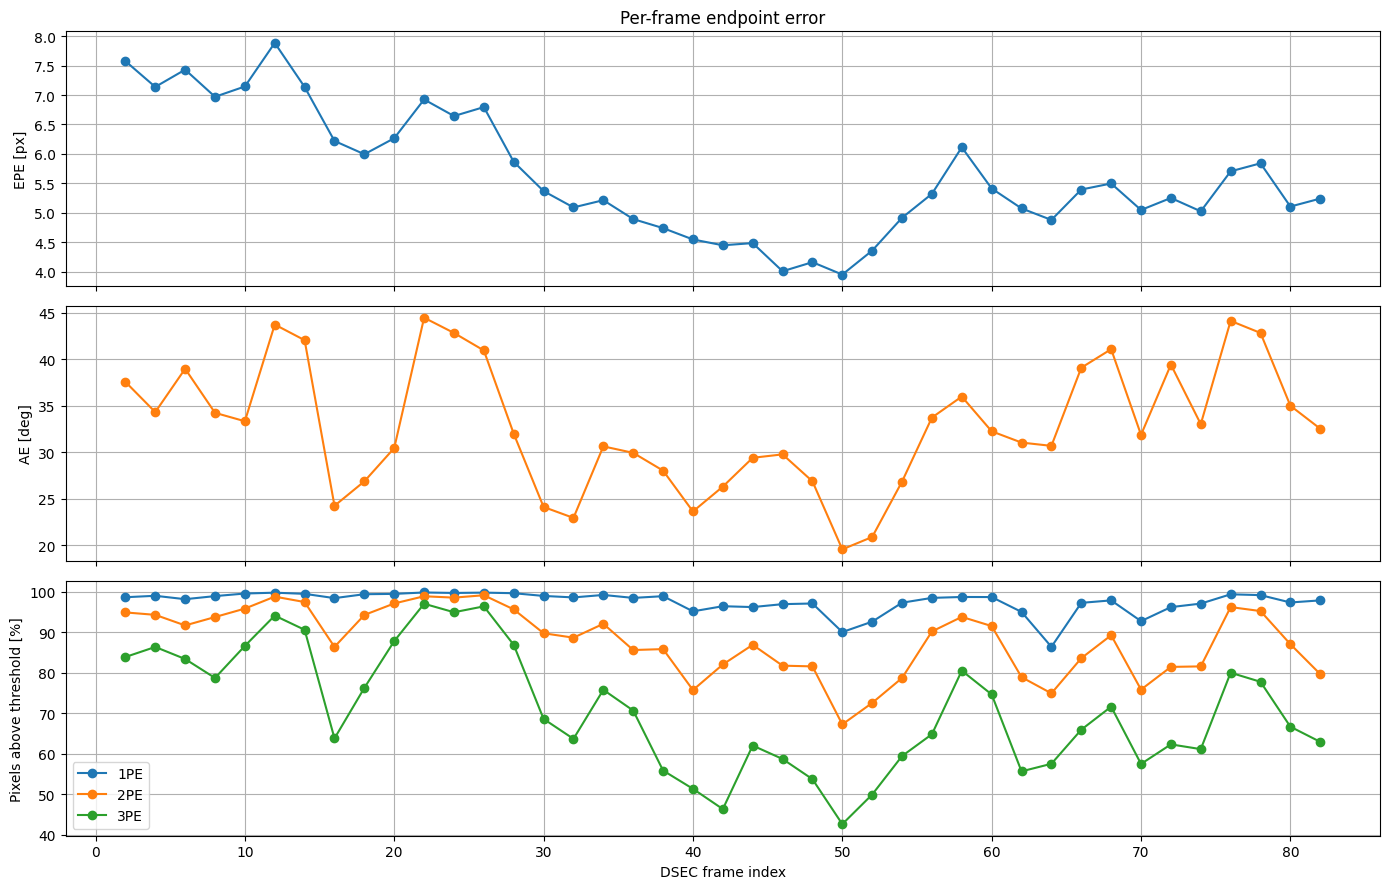

In [144]:
if df.empty:
    print("No current benchmark rows to plot.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(df["frame_index"], df["epe"], marker="o")
    axes[0].set_ylabel("EPE [px]")
    axes[0].set_title("Per-frame endpoint error")
    axes[1].plot(df["frame_index"], df["ae"], marker="o", color="tab:orange")
    axes[1].set_ylabel("AE [deg]")
    axes[2].plot(df["frame_index"], df["1pe_pct"], marker="o", label="1PE")
    axes[2].plot(df["frame_index"], df["2pe_pct"], marker="o", label="2PE")
    axes[2].plot(df["frame_index"], df["3pe_pct"], marker="o", label="3PE")
    axes[2].set_ylabel("Pixels above threshold [%]")
    axes[2].set_xlabel("DSEC frame index")
    axes[2].legend()
    plt.tight_layout()

In [145]:
cols = ["frame", "epe", "ae", "1pe_pct", "2pe_pct", "3pe_pct", "valid_pixels", "dt_ms"]
if df.empty:
    print("No current benchmark rows for best/worst tables.")
else:
    print("Worst frames by EPE")
    display(df.nlargest(10, "epe")[cols])
    print("Best frames by EPE")
    display(df.nsmallest(10, "epe")[cols])

Worst frames by EPE


,frame,epe,ae,1pe_pct,2pe_pct,3pe_pct,valid_pixels,dt_ms
5,000012.png,7.884388,43.742621,99.775222,98.804109,94.118887,56945,100.015
0,000002.png,7.575660,37.577601,98.656060,94.904310,83.899953,51416,100.001
2,000006.png,7.430505,38.984290,98.170709,91.695278,83.405324,54174,100.018
4,000010.png,7.145008,33.339002,99.568050,95.851852,86.639893,56025,99.982
1,000004.png,7.137556,34.322689,99.010218,94.306399,86.382489,53042,99.987
6,000014.png,7.136496,42.061078,99.491624,97.465354,90.614032,55274,99.932
3,000008.png,6.970292,34.245838,98.932756,93.764197,78.729043,55470,100.006
10,000022.png,6.924500,44.480539,99.826849,98.895721,97.045832,56598,100.002
12,000026.png,6.795082,40.956519,99.789448,99.145405,96.397608,56518,100.002
11,000024.png,6.643373,42.841053,99.708277,98.555705,94.947651,55875,99.986


Best frames by EPE


,frame,epe,ae,1pe_pct,2pe_pct,3pe_pct,valid_pixels,dt_ms
24,000050.png,3.952748,19.555485,90.053494,67.268358,42.650971,69914,100.006
22,000046.png,4.009163,29.775475,96.945741,81.763343,58.730990,62994,100.001
23,000048.png,4.163190,26.877526,97.109400,81.586364,53.750396,66353,100.006
25,000052.png,4.359611,20.884789,92.622653,72.573480,49.955297,71584,99.994
20,000042.png,4.449925,26.304983,96.438543,82.056520,46.365339,58740,100.009
21,000044.png,4.486888,29.406083,96.225485,86.910745,62.047896,60882,100.008
19,000040.png,4.548649,23.631215,95.171224,75.745257,51.367332,56826,99.998
18,000038.png,4.741285,28.026600,98.914006,85.853165,55.880812,55341,100.002
31,000064.png,4.880064,30.690958,86.410684,74.931043,57.545676,73234,100.018
17,000036.png,4.894562,29.938374,98.486646,85.622227,70.680370,54779,100.034


## DSEC PNG Sanity Checks

DSEC on-disk channel order is RGB = `(flow_x, flow_y, valid)`. OpenCV reads this as BGR, so the raw OpenCV channel 0 should be the valid mask. These checks catch the common channel-order bug immediately.

In [146]:
def raw_png_stats(path):
    raw = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if raw is None:
        raise FileNotFoundError(path)
    flat = raw.reshape(-1, raw.shape[-1])
    return {
        "file": path.name,
        "dtype": str(raw.dtype),
        "shape": raw.shape,
        "bgr_min": flat.min(axis=0).tolist(),
        "bgr_max": flat.max(axis=0).tolist(),
        "cv2_valid_unique": np.unique(raw[..., 0])[:10].tolist(),
        "valid_ratio": float((raw[..., 0] == 1).mean()),
    }

preferred = ["000002.png", "000004.png", "000082.png"]
if not df.empty:
    preferred.extend(df["frame"].head(3).tolist())
sample_files = []
for name in preferred:
    path = PRED_DIR / name
    if path.exists() and path not in sample_files:
        sample_files.append(path)

if not sample_files:
    print("No prediction PNGs available for raw DSEC encoding checks.")
else:
    display(pd.DataFrame([raw_png_stats(path) for path in sample_files]))
    for path in sample_files[:3]:
        frame = load_dsec_png(path)
        print(path.name, "decoded max |flow|", float(np.abs(frame.flow).max()), "valid ratio", float(frame.valid.mean()))

,file,dtype,shape,bgr_min,bgr_max,cv2_valid_unique,valid_ratio
0,000002.png,uint16,"(480, 640, 3)","[1, 31832, 29212]","[1, 34765, 34114]",[1],1.0
1,000004.png,uint16,"(480, 640, 3)","[1, 31931, 29225]","[1, 34770, 34029]",[1],1.0
2,000082.png,uint16,"(480, 640, 3)","[1, 32366, 31437]","[1, 34472, 33471]",[1],1.0
3,000006.png,uint16,"(480, 640, 3)","[1, 32085, 29589]","[1, 34666, 33940]",[1],1.0


000002.png decoded max |flow| 27.78125 valid ratio 1.0
000004.png decoded max |flow| 27.6796875 valid ratio 1.0
000082.png decoded max |flow| 13.3125 valid ratio 1.0


## Visualization Helpers

In [147]:
def flow_to_rgb(flow, valid=None, clip=None):
    """Middlebury-style HSV visualization for HxWx2 flow."""
    u = flow[..., 0]
    v = flow[..., 1]
    mag = np.sqrt(u * u + v * v)
    if clip is None:
        clip = np.nanpercentile(mag[np.isfinite(mag)], 99) if np.isfinite(mag).any() else 1.0
    clip = max(float(clip), 1e-6)
    ang = np.arctan2(v, u)
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.float32)
    hsv[..., 0] = ((ang + np.pi) / (2 * np.pi) * 179).astype(np.float32)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / clip, 0, 1) * 255
    rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    if valid is not None:
        rgb = rgb.copy()
        rgb[~valid] = 0
    return rgb


def load_pair(frame_name):
    gt_path = GT_DIR / frame_name
    pred_path = PRED_DIR / frame_name
    if not pred_path.exists():
        raise FileNotFoundError(f"Missing prediction PNG: {pred_path}")
    gt = load_dsec_png(gt_path)
    pred = load_dsec_png(pred_path)
    mask = gt.valid & np.isfinite(gt.flow).all(axis=-1) & np.isfinite(pred.flow).all(axis=-1)
    diff = pred.flow - gt.flow
    epe = np.linalg.norm(diff, axis=-1)
    return gt, pred, mask, epe


def show_frame(frame_name, error_clip=20.0, flow_clip=None):
    gt, pred, mask, epe = load_pair(frame_name)
    if flow_clip is None:
        both_mag = np.concatenate([
            np.linalg.norm(gt.flow[mask], axis=-1),
            np.linalg.norm(pred.flow[mask], axis=-1),
        ])
        flow_clip = np.percentile(both_mag, 99) if both_mag.size else 1.0
    row = df.loc[df["frame"] == frame_name].iloc[0]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()
    axes[0].imshow(flow_to_rgb(gt.flow, mask, clip=flow_clip))
    axes[0].set_title(f"GT flow {frame_name}")
    axes[1].imshow(flow_to_rgb(pred.flow, mask, clip=flow_clip))
    axes[1].set_title("MomentFlow prediction")
    im = axes[2].imshow(np.where(mask, epe, np.nan), cmap="turbo", vmin=0, vmax=error_clip)
    axes[2].set_title(f"EPE map, mean={row.epe:.2f}")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    axes[3].imshow(np.where(mask, gt.flow[..., 0], np.nan), cmap="coolwarm")
    axes[3].set_title("GT u")
    axes[4].imshow(np.where(mask, pred.flow[..., 0], np.nan), cmap="coolwarm")
    axes[4].set_title("Pred u")
    axes[5].hist(epe[mask].ravel(), bins=80, range=(0, error_clip))
    axes[5].set_title("EPE histogram")
    for ax in axes[:5]:
        ax.axis("off")
    plt.tight_layout()
    return gt, pred, mask, epe

## Inspect Worst Frames

Start with the highest-EPE frame, then change `frame_name` to inspect others.

Worst frame: 000012.png


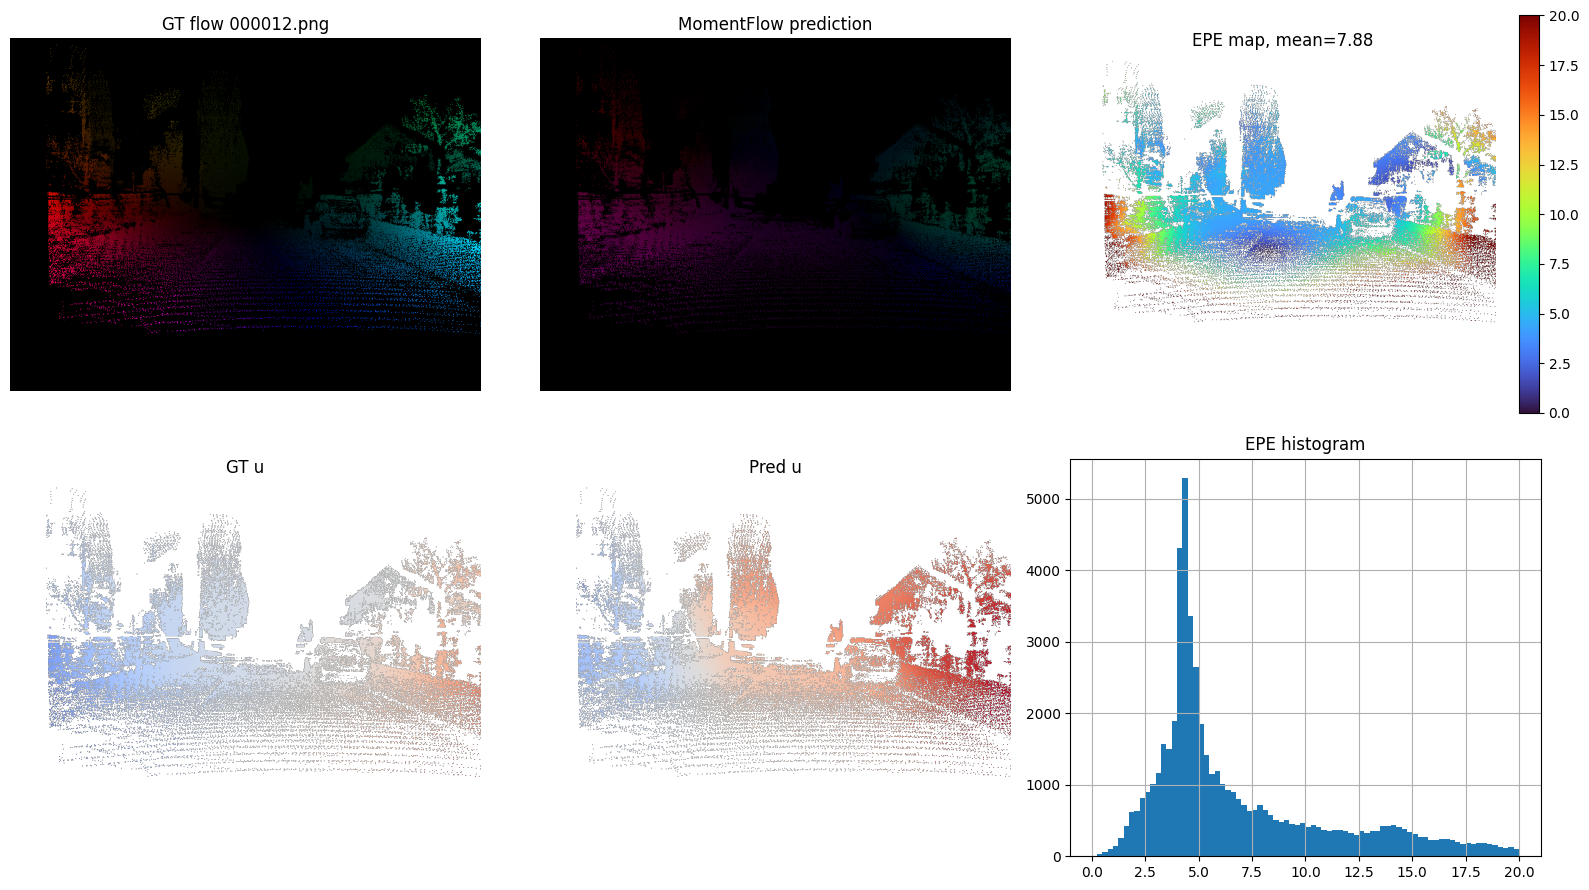

In [148]:
if df.empty:
    print("No current benchmark rows to inspect.")
else:
    worst_frame = df.sort_values("epe", ascending=False).iloc[0]["frame"]
    print("Worst frame:", worst_frame)
    _ = show_frame(worst_frame)

In [149]:
# Optional interactive frame browser. If ipywidgets is unavailable, this falls back to the worst frame.
if df.empty:
    print("No current benchmark rows for the frame browser.")
else:
    try:
        from ipywidgets import Dropdown, interact
        frame_dropdown = Dropdown(options=df["frame"].tolist(), value=worst_frame, description="frame")
        interact(lambda frame: show_frame(frame), frame=frame_dropdown)
    except Exception as exc:
        print("ipywidgets unavailable or disabled:", exc)
        _ = show_frame(worst_frame)

interactive(children=(Dropdown(description='frame', index=5, options=('000002.png', '000004.png', '000006.png'…

## Sign, Scale, And Axis Diagnostics

If a simple transform greatly improves EPE, the bug is probably not the estimator itself but a convention mismatch: wrong sign, swapped axes, velocity-vs-displacement scaling, or a time-base issue.

In [150]:
def iter_pairs(frame_names=None):
    if df.empty:
        return
    names = frame_names if frame_names is not None else df["frame"].tolist()
    for name in names:
        pred_path = PRED_DIR / name
        if pred_path.exists():
            yield name, *load_pair(name)

variants = {
    "identity": lambda f: f,
    "neg_xy": lambda f: -f,
    "flip_x": lambda f: np.dstack([-f[..., 0], f[..., 1]]),
    "flip_y": lambda f: np.dstack([f[..., 0], -f[..., 1]]),
    "swap_xy": lambda f: np.dstack([f[..., 1], f[..., 0]]),
    "swap_neg_xy": lambda f: -np.dstack([f[..., 1], f[..., 0]]),
}


def variant_score(transform):
    dot = 0.0
    norm = 0.0
    raw_epe_sum = 0.0
    count = 0
    for _, gt, pred, mask, _ in iter_pairs():
        p = transform(pred.flow)[mask].reshape(-1, 2).astype(np.float64)
        g = gt.flow[mask].reshape(-1, 2).astype(np.float64)
        dot += float((p * g).sum())
        norm += float((p * p).sum())
        raw_epe_sum += float(np.linalg.norm(p - g, axis=-1).sum())
        count += p.shape[0]
    if count == 0:
        return {"raw_epe": np.nan, "best_scalar": np.nan, "scaled_epe": np.nan}
    scale = dot / max(norm, 1e-12)
    scaled_epe_sum = 0.0
    for _, gt, pred, mask, _ in iter_pairs():
        p = transform(pred.flow)[mask].reshape(-1, 2).astype(np.float64) * scale
        g = gt.flow[mask].reshape(-1, 2).astype(np.float64)
        scaled_epe_sum += float(np.linalg.norm(p - g, axis=-1).sum())
    return {
        "raw_epe": raw_epe_sum / count,
        "best_scalar": scale,
        "scaled_epe": scaled_epe_sum / count,
    }

if df.empty:
    variant_df = pd.DataFrame()
    print("No current benchmark rows for sign/scale diagnostics.")
else:
    variant_df = pd.DataFrame([
        {"variant": name, **variant_score(fn)}
        for name, fn in variants.items()
    ]).sort_values("scaled_epe")
    display(variant_df)

,variant,raw_epe,best_scalar,scaled_epe
0,identity,5.763692,1.453202,5.976221
1,neg_xy,14.421848,-1.453202,5.976221
2,flip_x,12.592342,-0.621552,7.991662
3,flip_y,8.290100,0.621552,7.991662
4,swap_xy,11.151576,-0.254336,8.887917
5,swap_neg_xy,9.894393,0.254336,8.887917


In [151]:
# Fit a global 2x2 linear map pred @ A ~= gt from a random pixel sample.
if df.empty:
    print("No current benchmark rows for the global linear fit.")
else:
    rng = np.random.default_rng(0)
    P_samples = []
    G_samples = []
    for name, gt, pred, mask, _ in iter_pairs():
        ys, xs = np.where(mask)
        if ys.size == 0:
            continue
        take = rng.choice(ys.size, size=min(6000, ys.size), replace=False)
        p = pred.flow[ys[take], xs[take]].astype(np.float64)
        g = gt.flow[ys[take], xs[take]].astype(np.float64)
        P_samples.append(p)
        G_samples.append(g)
    if not P_samples:
        print("No valid pixels available for the global linear fit.")
    else:
        P = np.vstack(P_samples)
        G = np.vstack(G_samples)
        A, *_ = np.linalg.lstsq(P, G, rcond=None)  # P @ A ~= G
        raw_sample_epe = np.linalg.norm(P - G, axis=1).mean()
        fit_sample_epe = np.linalg.norm(P @ A - G, axis=1).mean()
        print("A maps [pred_u, pred_v] to [gt_u, gt_v]:")
        display(pd.DataFrame(A, index=["pred_u", "pred_v"], columns=["gt_u", "gt_v"]))
        print(f"sample raw EPE: {raw_sample_epe:.3f}")
        print(f"sample fitted-linear EPE: {fit_sample_epe:.3f}")

A maps [pred_u, pred_v] to [gt_u, gt_v]:


,gt_u,gt_v
pred_u,1.850484,0.165307
pred_v,0.326847,1.114195


sample raw EPE: 5.884
sample fitted-linear EPE: 5.336


Interpretation tips:

- `neg_xy` much better than `identity`: saved image-flow sign is probably flipped.
- `swap_xy` much better: x/y channel or coordinate convention is wrong.
- `best_scalar` near `0.1`, `10`, `100`, or `0.01`: likely velocity/displacement or timestamp scaling issue.
- A fitted 2x2 matrix that greatly improves EPE but is not close to diagonal suggests mixed axes or a rotation-like convention bug.

## Spatial Error Bias

A spatially concentrated error can point to rectification mismatch, border effects, tile-grid artifacts, or parts of the image with low event support.

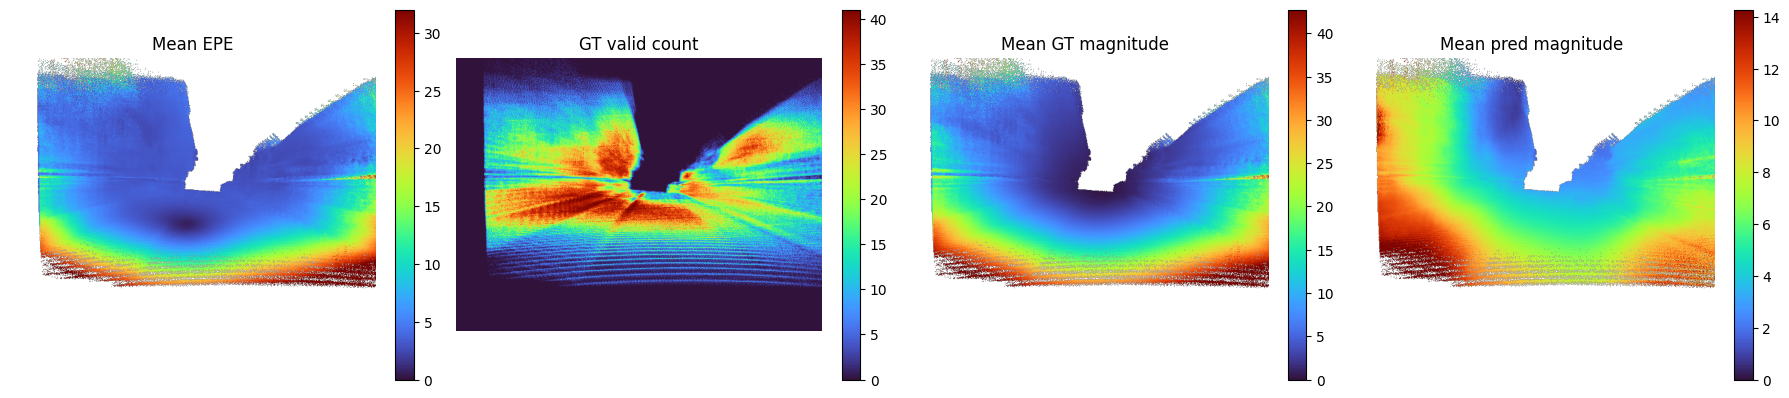

In [152]:
sum_epe = None
count = None
sum_gt_mag = None
sum_pred_mag = None
for _, gt, pred, mask, epe in iter_pairs():
    if sum_epe is None:
        sum_epe = np.zeros_like(epe, dtype=np.float64)
        count = np.zeros_like(epe, dtype=np.float64)
        sum_gt_mag = np.zeros_like(epe, dtype=np.float64)
        sum_pred_mag = np.zeros_like(epe, dtype=np.float64)
    sum_epe[mask] += epe[mask]
    count[mask] += 1
    sum_gt_mag[mask] += np.linalg.norm(gt.flow[mask], axis=-1)
    sum_pred_mag[mask] += np.linalg.norm(pred.flow[mask], axis=-1)

if sum_epe is None:
    print("No current prediction/GT pairs for spatial bias maps.")
else:
    mean_epe = np.divide(sum_epe, count, out=np.full_like(sum_epe, np.nan), where=count > 0)
    mean_gt_mag = np.divide(sum_gt_mag, count, out=np.full_like(sum_gt_mag, np.nan), where=count > 0)
    mean_pred_mag = np.divide(sum_pred_mag, count, out=np.full_like(sum_pred_mag, np.nan), where=count > 0)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, img, title, vmax in [
        (axes[0], mean_epe, "Mean EPE", np.nanpercentile(mean_epe, 98)),
        (axes[1], count, "GT valid count", np.nanmax(count)),
        (axes[2], mean_gt_mag, "Mean GT magnitude", np.nanpercentile(mean_gt_mag, 98)),
        (axes[3], mean_pred_mag, "Mean pred magnitude", np.nanpercentile(mean_pred_mag, 98)),
    ]:
        im = ax.imshow(img, cmap="turbo", vmin=0, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()

## Component And Magnitude Correlation

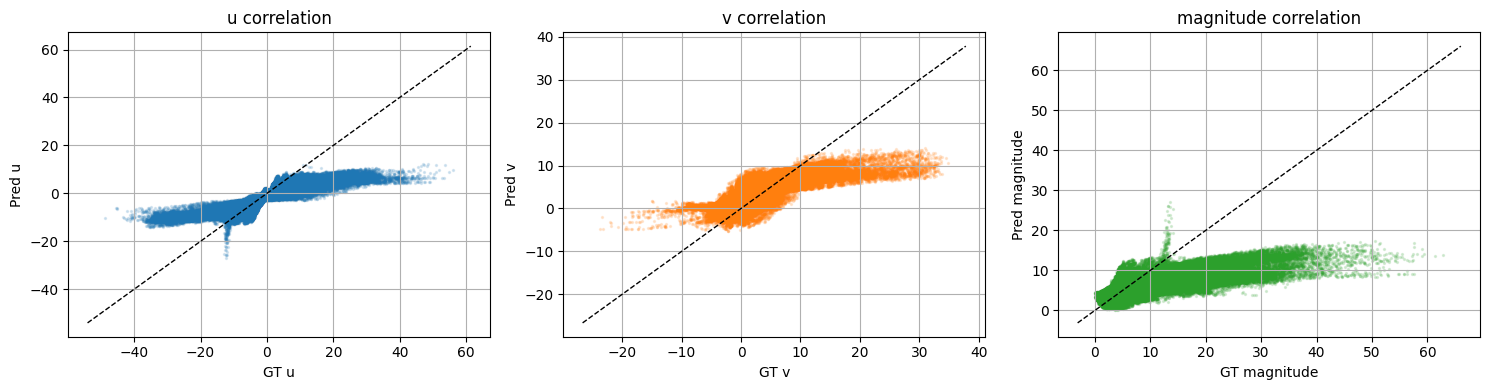

In [153]:
# Sample pixels for scatter plots.
rng = np.random.default_rng(1)
S_pred = []
S_gt = []
for _, gt, pred, mask, _ in iter_pairs():
    ys, xs = np.where(mask)
    if ys.size == 0:
        continue
    take = rng.choice(ys.size, size=min(2500, ys.size), replace=False)
    S_pred.append(pred.flow[ys[take], xs[take]])
    S_gt.append(gt.flow[ys[take], xs[take]])

if not S_pred:
    print("No current prediction/GT pairs for correlation scatter plots.")
else:
    S_pred = np.vstack(S_pred)
    S_gt = np.vstack(S_gt)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(S_gt[:, 0], S_pred[:, 0], s=2, alpha=0.15)
    axes[0].set_xlabel("GT u")
    axes[0].set_ylabel("Pred u")
    axes[0].set_title("u correlation")
    axes[1].scatter(S_gt[:, 1], S_pred[:, 1], s=2, alpha=0.15, color="tab:orange")
    axes[1].set_xlabel("GT v")
    axes[1].set_ylabel("Pred v")
    axes[1].set_title("v correlation")
    gt_mag = np.linalg.norm(S_gt, axis=1)
    pred_mag = np.linalg.norm(S_pred, axis=1)
    axes[2].scatter(gt_mag, pred_mag, s=2, alpha=0.15, color="tab:green")
    axes[2].set_xlabel("GT magnitude")
    axes[2].set_ylabel("Pred magnitude")
    axes[2].set_title("magnitude correlation")
    for ax in axes:
        lo, hi = ax.get_xlim()
        ylo, yhi = ax.get_ylim()
        mn, mx = min(lo, ylo), max(hi, yhi)
        ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.tight_layout()

## Timestamp And Output Completeness Checks

In [154]:
gt_files = sorted(GT_DIR.glob("*.png"))
pred_files = sorted(PRED_DIR.glob("*.png"))
expected = [p.name for p in gt_files]
actual = [p.name for p in pred_files]
missing = sorted(set(expected) - set(actual))
extra = sorted(set(actual) - set(expected))
print(f"GT PNGs: {len(gt_files)}  Pred PNGs: {len(pred_files)}")
print("missing:", missing[:20])
print("extra:", extra[:20])
if df.empty:
    print("Timestamp dt range unavailable until the benchmark has current rows.")
else:
    print("Timestamp dt range [ms]:", df["dt_ms"].min(), df["dt_ms"].max())
    display(df[["frame", "from_us", "to_us", "dt_ms", "valid_pixels", "epe"]].head(10))

GT PNGs: 41  Pred PNGs: 41
missing: []
extra: []
Timestamp dt range [ms]: 99.932 100.058


,frame,from_us,to_us,dt_ms,valid_pixels,epe
0,000002.png,49599300523,49599400524,100.001,51416,7.575660
1,000004.png,49599400524,49599500511,99.987,53042,7.137556
2,000006.png,49599500511,49599600529,100.018,54174,7.430505
3,000008.png,49599600529,49599700535,100.006,55470,6.970292
4,000010.png,49599700535,49599800517,99.982,56025,7.145008
5,000012.png,49599800517,49599900532,100.015,56945,7.884388
6,000014.png,49599900532,49600000464,99.932,55274,7.136496
7,000016.png,49600000464,49600100510,100.046,57232,6.220337
8,000018.png,49600100510,49600200516,100.006,57214,5.994848
9,000020.png,49600200516,49600300518,100.002,57536,6.267040


## Next Things To Try

Use the tables above to pick the next experiment:

1. If output completeness reports `Pred PNGs: 0`, rerun `event_detector_cpp` and check `flow_save_enabled`, `flow_save_output_dir`, the timestamp schedule path, and whether the node is being started before replay.
2. If sign/axis diagnostics improve a lot, fix the C++ save convention before tuning the algorithm.
3. If `best_scalar` is far from `1`, inspect whether the estimator is saved as px/s, px/ms, or displacement and whether `dt_us` is correct.
4. If errors are spatially localized, compare event rectification and GT rectified view assumptions.
5. If only a few frames dominate, open those frames with `show_frame("000xxx.png")` and inspect the flow/error maps.
6. If prediction magnitude is consistently too small, tune regularization/fallback/smoothing only after confirming timestamps and units are correct.